# Etap 1 — Baseline: segmentacja naczyń filtrem Frangiego

## 1. Przygotowanie środowiska

In [1]:
import sys, json
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from src import config, io_utils, metrics, visualize
from src import baseline, preprocessing
from src.config import TEST_IMAGES, RESULTS_DIR

## 2. Pipeline krok po kroku na jednym obrazie

Obraz: 14_h
  RGB shape: (2336, 3504, 3), dtype=uint8
  Manual mask: (2336, 3504), unique=[0 1]
  FOV mask:    (2336, 3504), unique=[0 1]
  Udział pikseli-naczyń wewnątrz FOV: 0.1033


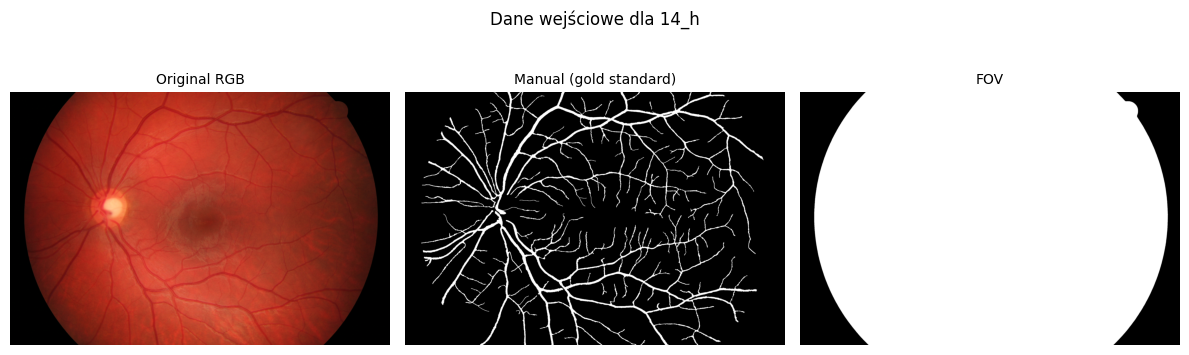

In [2]:
demo_id = TEST_IMAGES[0]
image, manual, fov = io_utils.load_triplet(demo_id)

print(f'Obraz: {demo_id}')
print(f'  RGB shape: {image.shape}, dtype={image.dtype}')
print(f'  Manual mask: {manual.shape}, unique={np.unique(manual)}')
print(f'  FOV mask:    {fov.shape}, unique={np.unique(fov)}')
print(f'  Udział pikseli-naczyń wewnątrz FOV: {(manual & fov).sum() / fov.sum():.4f}')

fig = visualize.compare_grid([
    ('Original RGB', image),
    ('Manual (gold standard)', manual * 255),
    ('FOV', fov * 255),
], ncols=3, suptitle=f'Dane wejściowe dla {demo_id}')
plt.show()

### 2.1 Wstępne przetwarzanie

Kanał zielony → wypełnienie poza FOV → CLAHE.

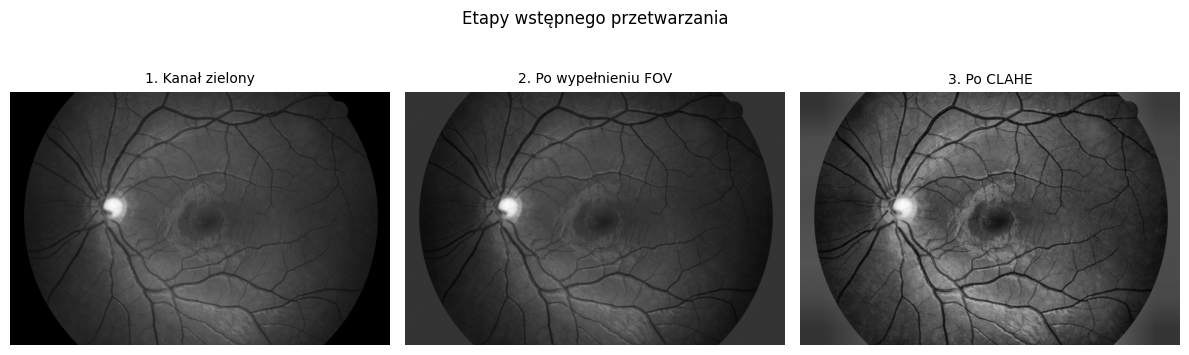

In [3]:
green = preprocessing.to_green_channel(image)
filled = preprocessing.fill_outside_fov(green, fov)
clahed = preprocessing.apply_clahe(filled, clip_limit=2.0, tile_grid_size=(8, 8))

fig = visualize.compare_grid([
    ('1. Kanał zielony', green),
    ('2. Po wypełnieniu FOV', filled),
    ('3. Po CLAHE', clahed),
], ncols=3, suptitle='Etapy wstępnego przetwarzania')
plt.show()

### 2.2 Filtr Frangiego

Detektor struktur tubularnych (vesselness). `black_ridges=True`, bo na kanale zielonym naczynia są ciemniejsze od tła.

Frangi response: dtype=float32, range=[0.000, 1.000]


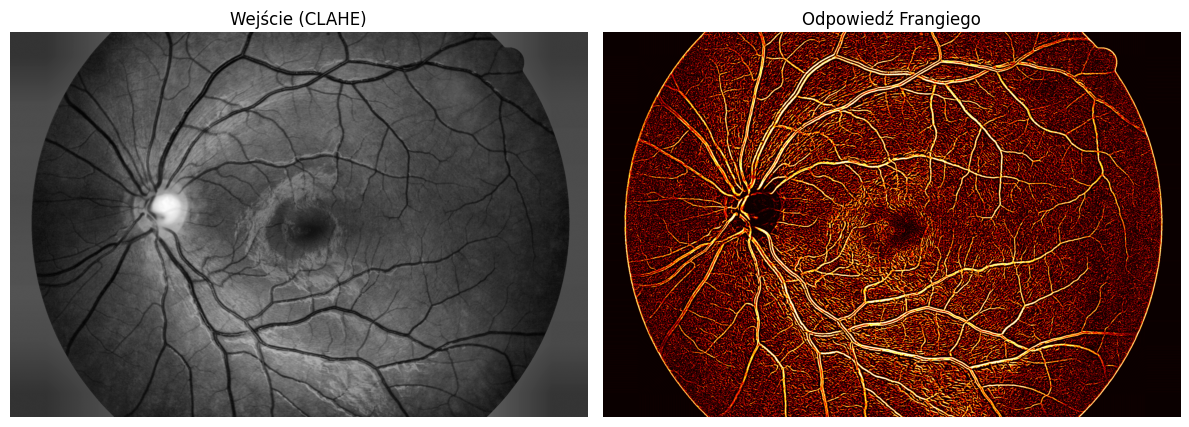

In [4]:
# scale=0.5 — downsampling przed Frangi przyspiesza filtr ~4x
# na pełnowymiarowym HRF (~3500×2300) prawie bez utraty jakości baseline.
frangi_resp = baseline.frangi_response(clahed, sigmas=(1, 2, 3, 4, 5), scale=0.5)
print(f'Frangi response: dtype={frangi_resp.dtype}, range=[{frangi_resp.min():.3f}, {frangi_resp.max():.3f}]')

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(clahed, cmap='gray'); ax[0].set_title('Wejście (CLAHE)'); ax[0].axis('off')
ax[1].imshow(frangi_resp, cmap='hot');  ax[1].set_title('Odpowiedź Frangiego'); ax[1].axis('off')
fig.tight_layout(); plt.show()

### 2.3 Progowanie i morfologia

Otsu liczone tylko po pikselach wewnątrz FOV, następnie zamknięcie i usunięcie małych komponentów.

/Volumes/MACFILES/university/Informatyka w Medycynie/DnoOka/src/baseline.py:170: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
/Volumes/MACFILES/university/Informatyka w Medycynie/DnoOka/src/baseline.py:172: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.


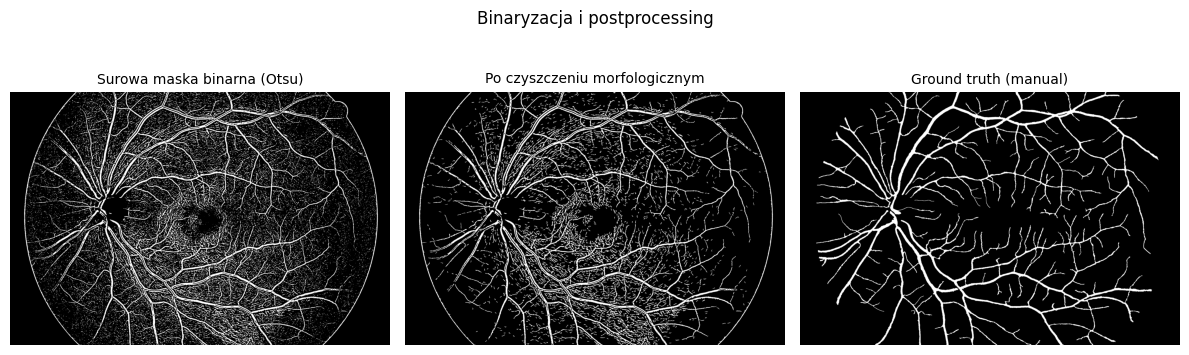

In [5]:
binary_raw = baseline.threshold_in_fov(frangi_resp, fov, method='otsu')
binary_clean = baseline.clean_mask(binary_raw, min_size=60, closing_radius=1)

fig = visualize.compare_grid([
    ('Surowa maska binarna (Otsu)', binary_raw * 255),
    ('Po czyszczeniu morfologicznym', binary_clean * 255),
    ('Ground truth (manual)', manual * 255),
], ncols=3, suptitle='Binaryzacja i postprocessing')
plt.show()

### 2.4 Metryki dla obrazu demo

Metryki dla 14_h:
  accuracy             = 0.9024
  sensitivity          = 0.7379
  specificity          = 0.9213
  precision            = 0.5194
  g_mean               = 0.8245
  balanced_accuracy    = 0.8296

Confusion matrix: TP=526900, FP=487598, TN=5708668, FN=187143


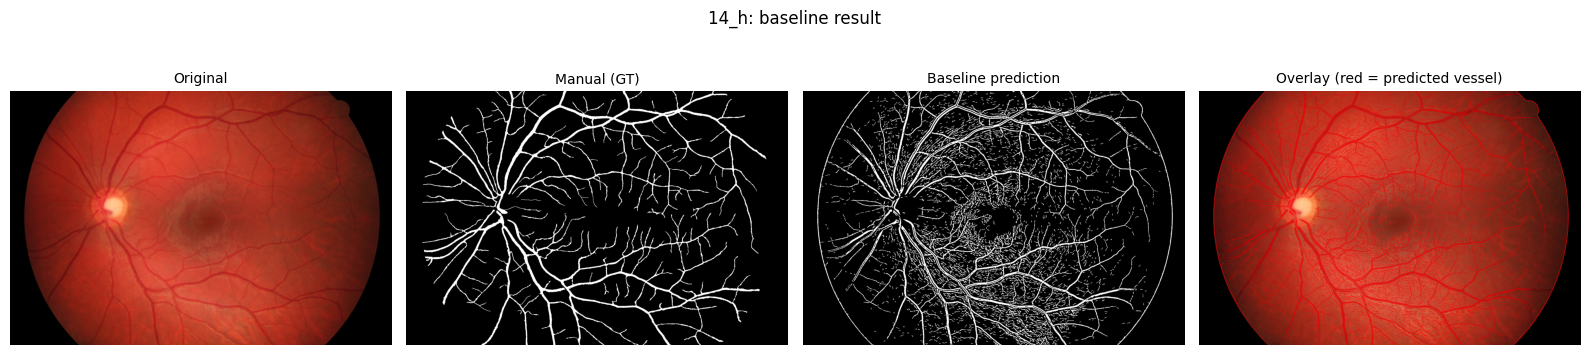

In [6]:
# Finalna maska = bin_clean & FOV (gwarancja braku detekcji poza FOV).
# Frangi POWYŻEJ już policzony — nie wywołujemy ponownie, reużywamy frangi_resp/binary_clean.
demo_mask = (binary_clean & (fov > 0)).astype('uint8')
demo_result = baseline.BaselineResult(
    preprocessed=clahed,
    frangi_response=frangi_resp,
    binary_raw=binary_raw,
    mask=demo_mask,
)
m = metrics.compute_metrics(demo_result.mask, manual, fov)

print(f'Metryki dla {demo_id}:')
for k in ['accuracy', 'sensitivity', 'specificity', 'precision', 'g_mean', 'balanced_accuracy']:
    print(f'  {k:20s} = {m[k]:.4f}')
print(f'\nConfusion matrix: TP={int(m["tp"])}, FP={int(m["fp"])}, TN={int(m["tn"])}, FN={int(m["fn"])}')

# Wizualizacja: oryginał | GT | predykcja | overlay
overlay_img = visualize.overlay(image, demo_result.mask, color=(255, 0, 0), alpha=0.6)
fig = visualize.compare_grid([
    ('Original', image),
    ('Manual (GT)', manual * 255),
    ('Baseline prediction', demo_result.mask * 255),
    ('Overlay (red = predicted vessel)', overlay_img),
], ncols=4, suptitle=f'{demo_id}: baseline result')
plt.show()

## 3. Ewaluacja na zbiorze testowym

In [7]:
per_image = {}
predictions = {}
for image_id in TEST_IMAGES:
    img, gt, fv = io_utils.load_triplet(image_id)
    res = baseline.predict(img, fv)
    m = metrics.compute_metrics(res.mask, gt, fv)
    per_image[image_id] = m
    predictions[image_id] = (img, gt, fv, res.mask)
    print(f'{image_id}: acc={m["accuracy"]:.4f}  sens={m["sensitivity"]:.4f}  '
          f'spec={m["specificity"]:.4f}  g_mean={m["g_mean"]:.4f}')

agg = metrics.aggregate(list(per_image.values()))
print('\n=== Statystyka zbiorcza (mean ± std) ===')
for k in ['accuracy', 'sensitivity', 'specificity', 'g_mean', 'balanced_accuracy']:
    print(f'  {k:20s} = {agg[k+"_mean"]:.4f} ± {agg[k+"_std"]:.4f}')

/Volumes/MACFILES/university/Informatyka w Medycynie/DnoOka/src/baseline.py:170: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
/Volumes/MACFILES/university/Informatyka w Medycynie/DnoOka/src/baseline.py:172: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.


14_h: acc=0.9024  sens=0.7379  spec=0.9213  g_mean=0.8245


/Volumes/MACFILES/university/Informatyka w Medycynie/DnoOka/src/baseline.py:170: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
/Volumes/MACFILES/university/Informatyka w Medycynie/DnoOka/src/baseline.py:172: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.


15_h: acc=0.9364  sens=0.6595  spec=0.9648  g_mean=0.7977


/Volumes/MACFILES/university/Informatyka w Medycynie/DnoOka/src/baseline.py:170: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
/Volumes/MACFILES/university/Informatyka w Medycynie/DnoOka/src/baseline.py:172: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.


...

15_dr: acc=0.8716  sens=0.6539  spec=0.8899  g_mean=0.7628


/Volumes/MACFILES/university/Informatyka w Medycynie/DnoOka/src/baseline.py:170: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
/Volumes/MACFILES/university/Informatyka w Medycynie/DnoOka/src/baseline.py:172: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.


14_g: acc=0.9234  sens=0.6841  spec=0.9452  g_mean=0.8042


/Volumes/MACFILES/university/Informatyka w Medycynie/DnoOka/src/baseline.py:170: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
/Volumes/MACFILES/university/Informatyka w Medycynie/DnoOka/src/baseline.py:172: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.


15_g: acc=0.9292  sens=0.6537  spec=0.9553  g_mean=0.7903

=== Statystyka zbiorcza (mean ± std) ===
  accuracy             = 0.9098 ± 0.0244
  sensitivity          = 0.6642 ± 0.0463
  specificity          = 0.9337 ± 0.0272
  g_mean               = 0.7870 ± 0.0296
  balanced_accuracy    = 0.7989 ± 0.0268


### 3.1 Tabela zbiorcza

In [8]:
df = pd.DataFrame(per_image).T[
    ['accuracy', 'sensitivity', 'specificity', 'precision', 'g_mean', 'balanced_accuracy']
]
df.loc['MEAN'] = df.mean()
df.loc['STD']  = df.iloc[:-1].std()
df.round(4)

,accuracy,sensitivity,specificity,precision,g_mean,balanced_accuracy
14_h,0.9024,0.7379,0.9213,0.5194,0.8245,0.8296
15_h,0.9364,0.6595,0.9648,0.6568,0.7977,0.8121
14_dr,0.8957,0.5961,0.9255,0.4428,0.7428,0.7608
15_dr,0.8716,0.6539,0.8899,0.3324,0.7628,0.7719
14_g,0.9234,0.6841,0.9452,0.5326,0.8042,0.8147
15_g,0.9292,0.6537,0.9553,0.5815,0.7903,0.8045
MEAN,0.9098,0.6642,0.9337,0.5109,0.7870,0.7989
STD,0.0244,0.0463,0.0272,0.1125,0.0296,0.0268


### 3.2 Porównanie wizualne GT vs predykcja

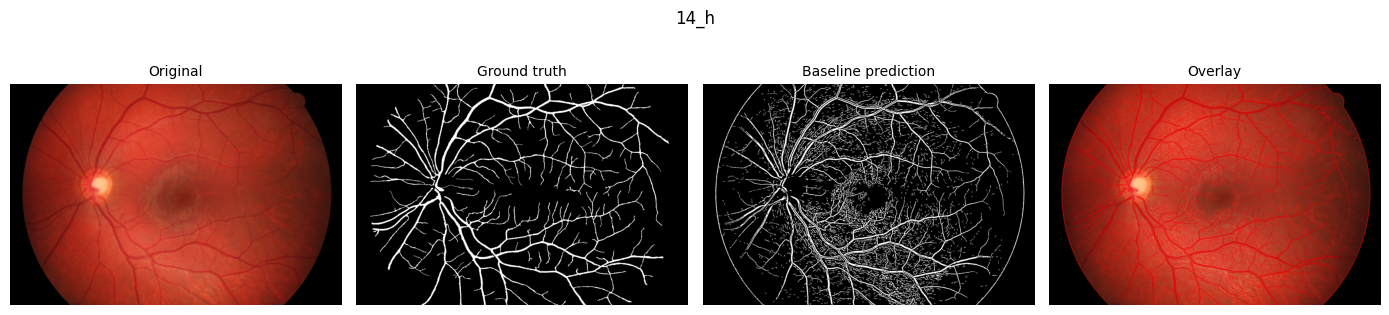

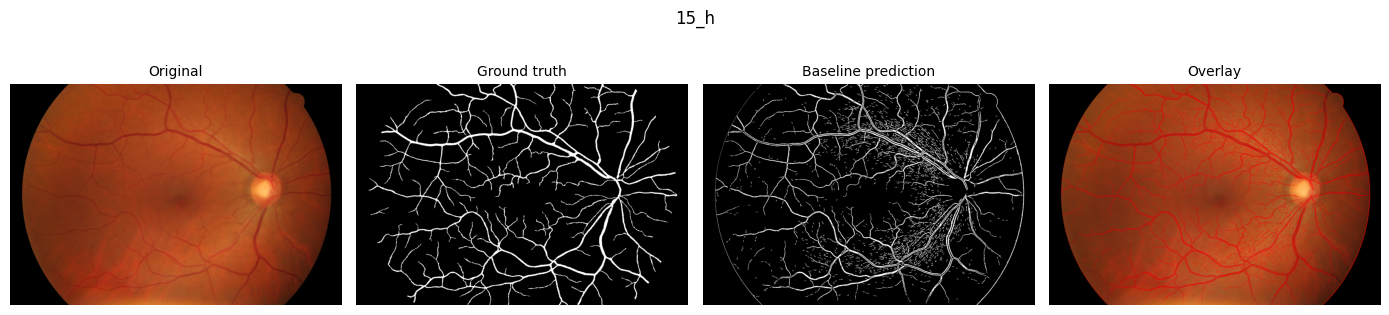

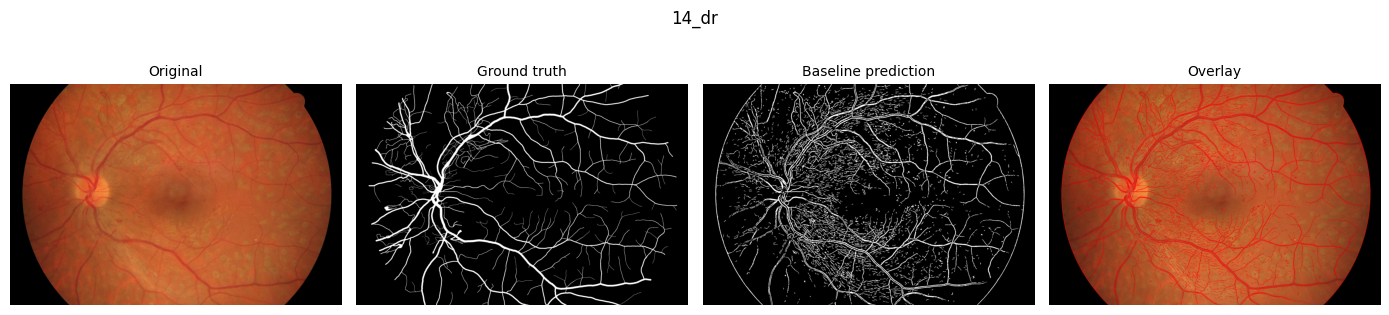

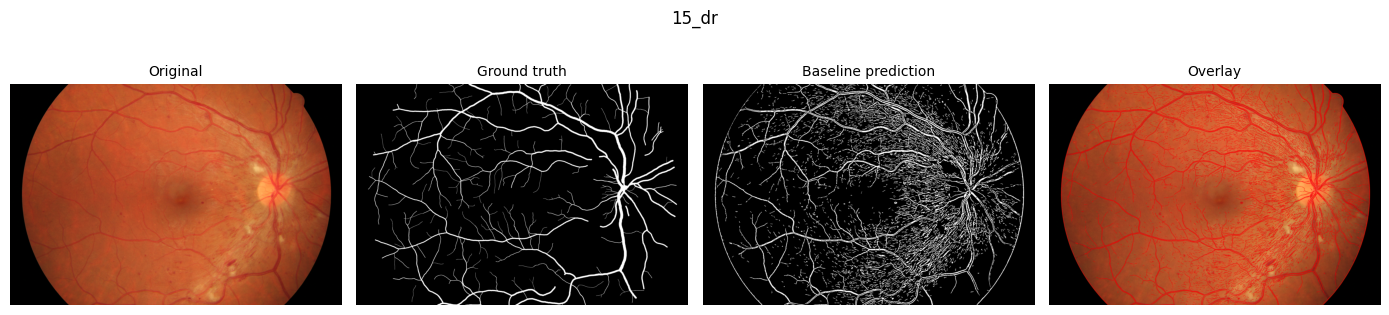

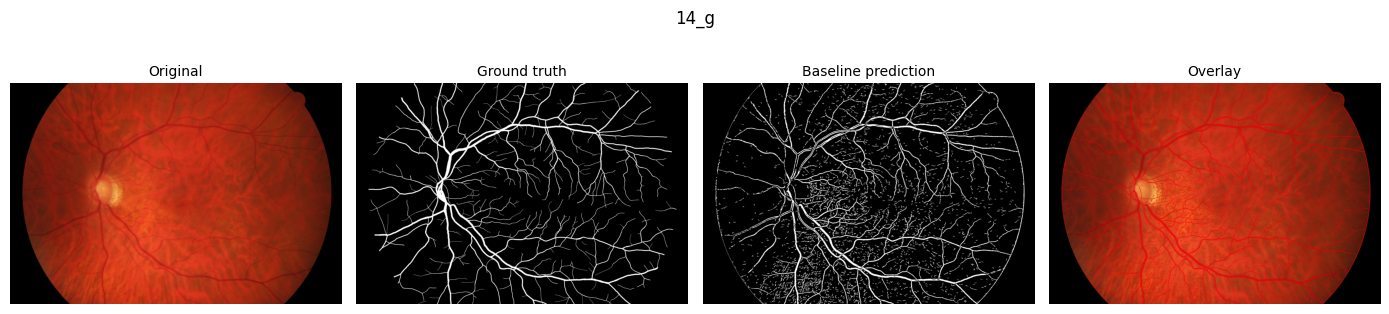

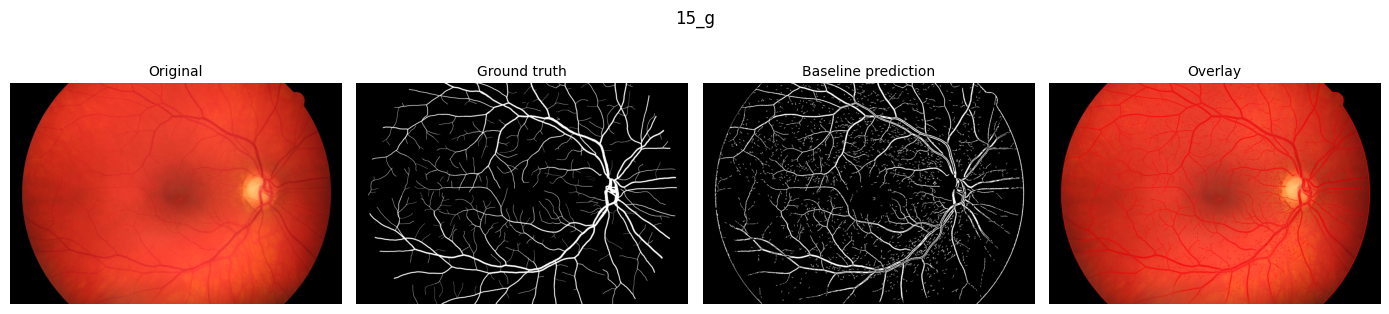

In [9]:
for image_id in TEST_IMAGES:
    img, gt, fv, pred = predictions[image_id]
    fig = visualize.compare_grid([
        ('Original', img),
        ('Ground truth', gt * 255),
        ('Baseline prediction', pred * 255),
        ('Overlay', visualize.overlay(img, pred, color=(255, 0, 0), alpha=0.6)),
    ], ncols=4, suptitle=image_id, figsize_per_panel=(3.5, 3.5))
    plt.show()

## 4. Zapis wyników do `results/baseline.json`

In [10]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
out_path = RESULTS_DIR / 'baseline.json'
payload = {
    'method': 'baseline_frangi_otsu',
    'params': {
        # Parametry pipeline — potrzebne do reprodukcyjności i zapisu w raporcie.
        'sigmas': [1, 2, 3, 4, 5],
        'frangi_scale': 0.5,
        'clahe_clip_limit': 2.0,
        'clahe_tile_grid': [8, 8],
        'threshold_method': 'otsu',
        'min_size': 60,
        'closing_radius': 1,
    },
    'test_images': list(TEST_IMAGES),
    'per_image': per_image,
    'aggregate': agg,
}
out_path.write_text(json.dumps(payload, indent=2, ensure_ascii=False))
print(f'Zapisano: {out_path}')

Zapisano: /Volumes/MACFILES/university/Informatyka w Medycynie/DnoOka/results/baseline.json
